In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

startup


In [5]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
    "use_gpu":use_gpu
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
  #  "use_gpu":use_gpu
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [6]:
if(use_gpu):
    xp=cp
else:
    xp=np

# [ 1.00000000e+06,  1.00000000e+04,  9.00000000e-01,
#          2.85813146e+01,  5.00000000e-01,  1.00000000e+00,
#          3.31765439e+01,  1.04719755e+00,  7.85398163e-01,
#          6.28318531e-01,  5.23598776e-01,  1.00000000e-01,
#          2.00000000e-01,  3.00000000e-01,  1.00000000e+01,
#          2.50000000e-01,  9.50000000e-01]

m1 = 1e6
m2 = 1e4
a = 0.9 
p0 = 2.85813146e+01
#p0 = 42.0
e0 = 5.00000000e-01
xI0 = 1.0
dist = 3.31765439e+01/2
#dist = 5.0
qS = 1.04719755e+00
phiS = 7.85398163e-01
qK = 6.28318531e-01

phiK =5.23598776e-01
Phi_phi0 = 0.1
Phi_theta0 =0.2
Phi_r0 = 0.3

dt = 10.0
T = 0.25
chi2 = 9.50000000e-01

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True


print(use_gpu)
pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

emri_kwargs = {"T":T, "dt":dt}

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

True


In [7]:
der_order = 8
Ndelta=10
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

OutOfMemoryError: Out of memory allocating 32,335,872 bytes (allocated so far: 19,992,095,744 bytes).

Body is not plunging, Fisher should be stable.
waveform shape: (2, 788954)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10000.0, 0.9, 28.5813146, 0.5, 1.0, 1.658827195, 1.04719755, 0.785398163, 0.628318531, 0.523598776, 0.1, 0.2, 0.3, 0.95, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 201.914303909007
calculating stable deltas...
Gamma_ii for m1: 1511.5372492567935
Gamma_ii for m1: 1511.5372491894411
Gamma_ii for m1: 1511.5372491265366
Gamma_ii for m1: 1511.5372490979535
Gamma_ii for m1: 1511.5372492355486
Gamma_ii for m1: 1511.5372498156912
Gamma_ii for m1: 1511.5372479366772
Gamma_ii for m1: 1511.537217127116
Gamma_ii for m1: 1511.53714500669
Gamma_ii for m1: 1511.5378883328458
[np.float64(4.455887726368394e-11), np.float64(4.161625455373232e-11), np.float64(1.8909983698401337e-11), np.float64(9.102996288319051e-11), np.float64(3.8380964063048626e-10), np.float64(1.243114590834422e-09), np.float64(2.038293256566094e-08), np.float64(4.771

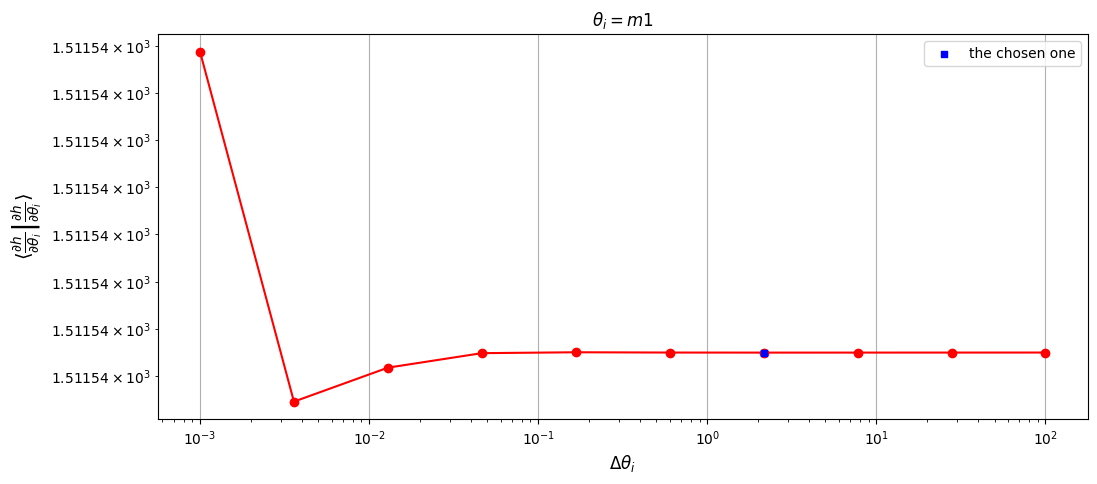

Gamma_ii for m2: 2522935.270486013
Gamma_ii for m2: 2522935.2703584903
Gamma_ii for m2: 2522935.270395837
Gamma_ii for m2: 2522935.2697791047
Gamma_ii for m2: 2522935.269139893
Gamma_ii for m2: 2522935.270488336
Gamma_ii for m2: 2522935.2942234217
Gamma_ii for m2: 2522935.214908699
Gamma_ii for m2: 2522935.6740994235
Gamma_ii for m2: 2522936.7732574814
[np.float64(5.054538735548546e-11), np.float64(1.480279789243602e-11), np.float64(2.444502087890224e-10), np.float64(2.5336038539006545e-10), np.float64(5.34474009344384e-10), np.float64(9.407726609799052e-09), np.float64(3.143747893757379e-08), np.float64(1.8200651294111096e-07), np.float64(4.3566611323509793e-07)]
1


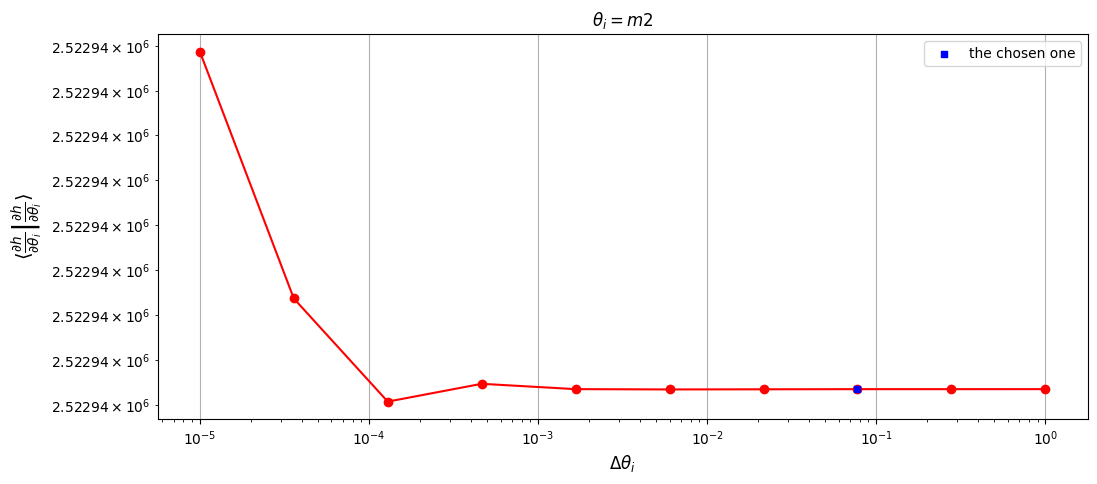

Gamma_ii for a: 3272496168160.9517
Gamma_ii for a: 3272498200293.3667
Gamma_ii for a: 3272474294839.6553
Gamma_ii for a: 3272523987398.523
Gamma_ii for a: 3272588358707.9023
Gamma_ii for a: 3272168143798.674
Gamma_ii for a: 3272944992072.7827
Gamma_ii for a: 3273399025517.8823
Gamma_ii for a: 3277836725337.538
Gamma_ii for a: 3430449606631.737
[np.float64(6.209728136311549e-07), np.float64(7.305008858013689e-06), np.float64(1.5184780633855228e-05), np.float64(1.9669846104570847e-05), np.float64(0.00012842094011119074), np.float64(0.00023735451588414945), np.float64(0.00013870397148657337), np.float64(0.0013538501736076515), np.float64(0.044487719918452635)]
0


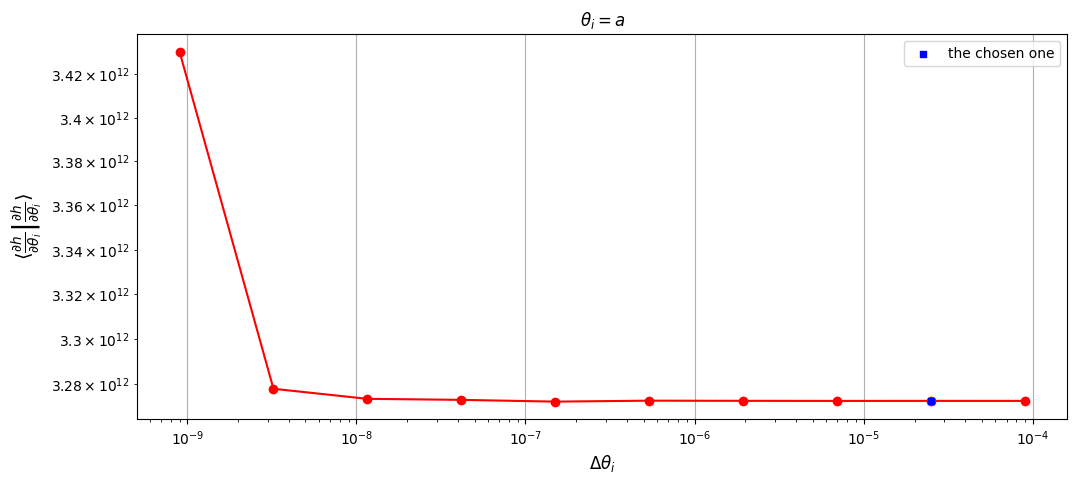

Gamma_ii for p0: 6819022633216.187
Gamma_ii for p0: 6819022746692.23
Gamma_ii for p0: 6819022692630.262
Gamma_ii for p0: 6819023609755.759
Gamma_ii for p0: 6819026468099.8955
Gamma_ii for p0: 6819014939038.407
Gamma_ii for p0: 6818981664345.989
Gamma_ii for p0: 6818990937521.595
Gamma_ii for p0: 6819027130762.33
Gamma_ii for p0: 6818581951719.424
[np.float64(1.6641100662167085e-08), np.float64(7.928110989926474e-09), np.float64(1.344951344292474e-07), np.float64(4.1917187887308794e-07), np.float64(1.6907224271174622e-06), np.float64(4.879715778083139e-06), np.float64(1.3599043744790698e-06), np.float64(5.307683932224707e-06), np.float64(6.528909472063915e-05)]
1


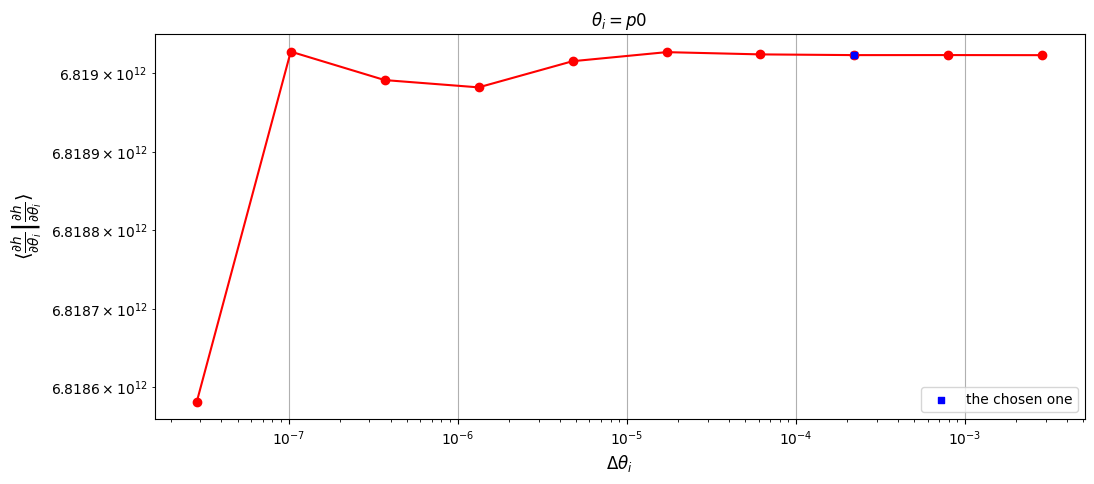

Gamma_ii for e0: 273169108936828.97
Gamma_ii for e0: 273169081946618.34
Gamma_ii for e0: 273169022459195.56
Gamma_ii for e0: 273169721209774.06
Gamma_ii for e0: 273168574289992.88
Gamma_ii for e0: 273167052555597.4
Gamma_ii for e0: 273137220293292.75
Gamma_ii for e0: 272963425843415.1
Gamma_ii for e0: 273303878586744.47
Gamma_ii for e0: 272438739544835.56
[np.float64(9.880404631690464e-08), np.float64(2.1776782098393275e-07), np.float64(2.557935687035429e-06), np.float64(4.198578786628443e-06), np.float64(5.570709868676542e-06), np.float64(0.0001092207875317124), np.float64(0.0006366950053497389), np.float64(0.001245693054521793), np.float64(0.0031755360612602205)]
0


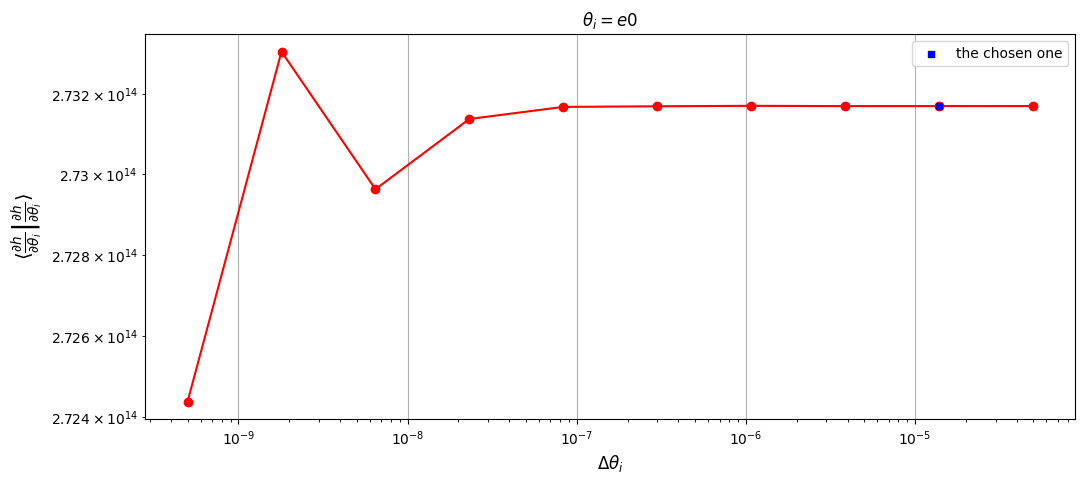

stable deltas: {'m1': 2.1544346900318834, 'm2': 0.0774263682681127, 'a': 2.5043034619864152e-05, 'p0': 0.00022129473898063854, 'e0': 1.3912797011035628e-05}
Time taken to compute stable deltas is 26.586864709854126 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 2.4914751052856445 seconds


In [ ]:
#initialize the 0PA (approximate) model
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
deviation_included=True
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}


param_names = ['m1','m2','a','p0','e0']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,
            )


In [ ]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J
fisher_=logmasstransform(Fisher, m1, index_of_m1 = 0)
cov=np.linalg.inv(fisher_)
std= np.sqrt(np.diag(cov))
params_truth_in = np.array([np.log(m1), m2, a, p0, e0])

In [ ]:
deviation_included=True
evolve_1PA=True
evolve_primary=False
evolve_2PA=False
use_gpu=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)
print(add_args)

waveform_true = superkludge_wave(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
waveform_true=xp.array(waveform_true)
waveform_true

[0.95, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


array([[ 1.74749107e-20,  1.88856152e-20,  2.02361802e-20, ...,
         1.01107469e-19,  9.52820799e-20,  8.77788922e-20],
       [ 4.38560946e-20,  4.29024432e-20,  4.19109522e-20, ...,
        -2.54720559e-20, -3.89776346e-20, -5.11994912e-20]],
      shape=(2, 788954))

In [ ]:
deviation_included=False
evolve_1PA=False
evolve_primary=False
evolve_2PA=False
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

def loglike_calc(m1_, m2_, a_, p0_, e0_):
    waveform_temp=xp.array(superkludge_wave(m1_, m2_, a_, p0_, e0_, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T,use_gpu=use_gpu))
    diff_inner=inner_product(waveform_true-waveform_temp,waveform_true-waveform_temp,PSD,dt,use_gpu=use_gpu)
    return -0.5 * diff_inner

def timemax_correlation( h1, h2):

    # FFT with dt scaling
    H1 = xp.fft.fft(h1) * dt
    H2 = xp.fft.fft(h2) * dt

    Y = xp.zeros_like(H1)
    Y[1:] = H1[1:] * xp.conj(H2[1:]) / (0.5 * PSD[1:])  # Avoid DC component
    # IFFT to time domain with proper normalization
    S = xp.fft.ifft(Y) / dt
    # Return maximum correlation
    return xp.max(xp.abs(S))

def loglike_calc_time_max(m1_, m2_, a_, p0_, e0_):
    waveform_temp=xp.array(superkludge_wave(m1_, m2_, a_, p0_, e0_, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T,use_gpu=use_gpu))
    max_corr = timemax_correlation(waveform_true, waveform_temp)
    return max_corr


In [ ]:
def log_density(params):
    params = np.asarray(params)
    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)
    for i in range(n_samples):
        logm1_, m2_, a_, p0_, e0_ = params[i]
        m1_ = np.exp(logm1_)
        loglike = loglike_calc_time_max(m1_, m2_, a_, p0_, e0_)
        log_likes[i] = loglike 
    return log_likes

n=350
logm1lim = [max(0,params_truth_in[0] - n*std[0]), params_truth_in[0] + n*std[0]]
m2lim = [max(0,params_truth_in[1] - n*std[1]), params_truth_in[1] + n*std[1]]
alim = [max(-0.999,params_truth_in[2] - n*std[2]), min(params_truth_in[2] + n*std[2], 0.999)]  # a must be <1
p0lim = [max(0,params_truth_in[3] - n*std[3]), params_truth_in[3] + n*std[3]]
e0lim = [max(0,params_truth_in[4] - n*std[4]), min(1,params_truth_in[4] + n*std[4])]

def prior_transform(u):

    transformed = np.zeros_like(u)
    # Uniform in log for masses
    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    transformed[:, 1] = (m2lim[1] - m2lim[0]) * u[:, 1] + m2lim[0]
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    return transformed
    
def inverse_prior_transform(x):
    
    u = np.zeros_like(x)

    u[:, 0] = (x[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (x[:, 1] - m2lim[0]) / (m2lim[1] - m2lim[0])
    u[:, 2] = (x[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (x[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (x[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    
    return u

In [ ]:
logm1lim = [max(0,params_truth_in[0] - n*std[0]), params_truth_in[0] + n*std[0]]
m2lim = [max(0,params_truth_in[1] - n*std[1]), params_truth_in[1] + n*std[1]]
alim = [max(-0.999,params_truth_in[2] - n*std[2]), min(params_truth_in[2] + n*std[2], 0.999)]  # a must be <1
p0lim = [max(0,params_truth_in[3] - n*std[3]), params_truth_in[3] + n*std[3]]
e0lim = [max(0,params_truth_in[4] - n*std[4]), min(1,params_truth_in[4] + n*std[4])]

ranges=[logm1lim, m2lim, alim, p0lim, e0lim]
ranges

[[np.float64(13.755916522321797), np.float64(13.87510459360675)],
 [np.float64(9850.677465106979), np.float64(10149.322534893021)],
 [np.float64(0.8070962816995084), np.float64(0.9929037183004916)],
 [np.float64(27.56410901685771), np.float64(29.598520183142288)],
 [np.float64(0.4961937565916358), np.float64(0.5038062434083642)]]

In [ ]:
# def main():
    
config = SamplerConfig(
        merge_confidence=0.9,          # Coverage prob → Mahalanobis merge radius R_m (higher is more permissive)
        alpha=1000,                    # Use recent samples for weighting
        trail_size=int(1e3),          # Maximum trials per iteration
        boundary_limiting=True,        # Enable boundary constraints
        use_beta=True,                # Use beta correction for boundaries
        integral_num=int(1e5),        # MC samples for beta estimation
        gamma=100,                    # Covariance update frequency
        exclude_scale_z=np.inf,       # No exclusion based on weights
        use_pool=False,               # Set to True for multiprocessing
        #n_pool=4                      # Number of processes (if use_pool=True)
    )

ndim = 100
n_seed = int(1e3)  # Number of initial processes
init_cov_list = [np.eye(ndim) * 1e-10] * n_seed
savepath = 'paris_1PA_vs_0PA_5_timemax'  # Directory to save results

# Create save directory
os.makedirs(savepath, exist_ok=True)

print(f"Problem dimension: {ndim}")
print(f"Number of processes: {n_seed}")
print(f"Save path: {savepath}")
print(f"Multiprocessing: {config.use_pool}")
# Initialize sampler
print("\nInitializing sampler...")
sampler = Sampler(
    ndim=ndim, 
    n_seed=n_seed,
    log_density_func=log_density,
    init_cov_list=init_cov_list,
    prior_transform=prior_transform,
    config=config
)
   # Prepare initial samples using Latin Hypercube Sampling
print("Preparing LHS samples...")

#best value got so far
sampler.prepare_lhs_samples(lhs_num=int(1e5), batch_size=100)

# print("Shape of points array:", external_lhs_points.shape)
# external_lhs_log_densities = log_density(prior_transform(external_lhs_points))
# print("true points in corrrect space",params_truth_in)
# print("external_lhs_log_densities", external_lhs_log_densities)


sampler.run_sampling(
            num_iterations=int(1e5),
            savepath=savepath,
            print_iter=100,
        #    external_lhs_points=external_lhs_points,
       #     external_lhs_log_densities=external_lhs_log_densities,
            stop_dlogZ=0.01
        )


print("Extracting results...")
samples_, weights_ = sampler.get_samples_with_weights(flatten=True)

# Basic analysis
print(f"\nResults Summary:")
print(f"Total samples: {len(samples_)}")
print(f"Effective sample size: {1/np.sum(weights_  **2):.1f}")

# Weighted statistics
weighted_mean = np.average(samples_, weights=weights_, axis=0)
weighted_cov = np.cov(samples_.T, aweights=weights_)

print(f"\nTrue values: {params_truth_in}")
print(f"Estimated deviation: {weighted_mean}")
print(f"Mean deviation: {np.linalg.norm(weighted_mean - params_truth_in[0:5]):.6f}")

print(f"\nTrue covariance diagonal: {np.diag(cov)}")
print(f"Estimated covariance diagonal: {np.diag(weighted_cov)}")

Problem dimension: 5
Number of processes: 1000
Save path: paris_1PA_vs_0PA_5_params
Multiprocessing: False

Initializing sampler...
Preparing LHS samples...


Computing LHS densities:   0%|          | 0/1000 [00:00<?, ?it/s]

ValueError: Integration did not converge within max_iter.

In [11]:
# best_fit_tn=external_lhs_points[np.argmax(external_lhs_log_densities)]
# print(np.max(external_lhs_log_densities))
# print(best_fit_tn)
# prior_transform(np.array([best_fit_tn]))

In [29]:
params_truth_in

array([1.38155106e+01, 1.00000000e+04, 9.00000000e-01, 2.85813146e+01,
       5.00000000e-01])

## [-69.13796993]
### [1.38248282e+01,9.98450218e+03,9.12758229e-01,2.84569154e+01,4.97916535e-01]

## array([-40.03242833])
### [1.38248471e+01, 9.98461888e+03, 9.12789122e-01, 2.84566945e+01, 4.97908665e-01]

## 
### [1.38248252e+01,9.98451128e+03,9.12756355e-01,2.84569341e+01,4.97915593e-01]

##
### [1.38251836e+01,9.98387483e+03,9.13306537e-01,2.84510455e+01,4.97884338e-01]

#

In [48]:
print(log_density([params_truth_in[0:5]]))
log_density([ [1.38251836e+01,9.98387483e+03,9.13306537e-01,2.84510455e+01,4.97884338e-01]])


[-33335.2029413]


array([-4002.38962062])

In [49]:
inverse_prior_transform(np.array([[1.38248471e+01, 9.98461888e+03, 9.12789122e-01, 2.84566945e+01, 4.97908665e-01]]))

array([[0.57833453, 0.44849699, 0.56882998, 0.4387439 , 0.22527571]])

In [36]:
best_fit_point = [1.38251836e+01,9.98387483e+03,9.13306537e-01,2.84510455e+01,4.97884338e-01]

In [37]:
add_args

[0.95, False, False, False, False, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

In [38]:
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

waveform_approx = superkludge_wave(np.exp(best_fit_point[0]), best_fit_point[1], best_fit_point[2], best_fit_point[3],
                                    best_fit_point[4], xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
diff_inner_bf=inner_product(waveform_approx,waveform_true,PSD,dt,use_gpu=use_gpu)
norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
norm_bf=np.sqrt(inner_product(waveform_approx,waveform_approx,PSD,dt,use_gpu=use_gpu))
overlap_bf=diff_inner_bf/((norm_true)*norm_bf)
print("overlap between best fit point and true waveform:", overlap_bf)
print("mismatch between best fit point and true waveform:", 1-overlap_bf)

overlap between best fit point and true waveform: 0.8703736643512113
mismatch between best fit point and true waveform: 0.12962633564878867


In [ ]:
def timemax_correlation(self, h1, h2):
    """
    Find maximum noise-weighted correlation between two waveforms.
    Uses FFT-based correlation with LISA noise weighting to find the maximum
    correlation over all time shifts.
    Parameters:
    -----------
    h1, h2 : array
        Time-domain waveforms (complex arrays)
    Returns:
    --------
    float
        Maximum correlation value over all time shifts
    """
    # FFT with dt scaling
    H1 = self.xp.fft.fft(h1) * self.dt
    H2 = self.xp.fft.fft(h2) * self.dt
    # Get PSD at full FFT frequencies (skip DC), using absolute value for negative frequencies
    Sn = self.xp.asarray(get_sensitivity(self.xp.abs(self.fft_freqs[1:]), sens_fn=CornishLISASens, return_type="PSD"))
    # Initialize Y with zeros
    Y = self.xp.zeros_like(H1)
    # Noise-weighted correlation (skip DC)
    Y[1:] = H1[1:] * self.xp.conj(H2[1:]) / (0.5 * Sn)
    # IFFT to time domain with proper normalization
    S = self.xp.fft.ifft(Y) / self.dt
    # Return maximum correlation
    return self.xp.max(self.xp.abs(S))

def Xstat_timemax(self, x, h):
        """
        Compute time-and-phase-maximized detection statistic with PSD weighting.

        Returns max_τ,φ |<x|h(τ,φ)>|_weighted / sqrt(<h|h>)

        Should peak at SNR when x=h.
        Uses FFT-based cross-correlation to efficiently maximize over all time shifts.

        Parameters:
        -----------
        x : array
            Time-domain data signal
        h : array
            Time-domain template waveform

        Returns:
        --------
        float
            Maximum correlation over time and phase shifts normalized by template SNR
        """
        # Time-maximized correlation
        calc_inner_complex = self.timemax_correlation(x, h)
        calc_SNR = self.xp.sqrt(self.timemax_correlation(h, h))

        # Normalized detection statistic
        return calc_inner_complex / calc_SNR
    
def Xstat(self, x, h):
        """
        Compute the standard detection statistic for gravitational wave data.

        Returns |<x|h>| / sqrt(<h|h>)
        """

        xf = self.freq_wave(x)
        hf = self.freq_wave(h)

        # Get COMPLEX inner product for phase maximization
        calc_inner_complex = self.inner(xf, hf, return_complex=True)
        calc_SNR = self.xp.sqrt(self.inner(hf, hf))

        # NOTE: Phase-marginalized (maximizes over Phi_phi0, Phi_r0, etc)
        return self.xp.abs(calc_inner_complex) / calc_SNR

        # NOTE: Phase-dependent version
        # calc_inner_real = self.inner(xf, hf, return_complex=False)
        # return calc_inner_real / calc_SNR


def inner(self, h1f, h2f, return_complex=False):
        """
        Compute the inner product of two gravitational waveforms.

        Parameters:
        h1f, h2f (numpy.ndarray or cupy.ndarray): Frequency domain waveforms.
        return_complex (bool): If True, return complex inner product.
                               If False, return real part only (default, backward compatible)

        Returns:
        float or complex: Inner product of the two waveforms.
        """

        df = 1/(self.N*self.dt)  # Frequency resolution

        # Get sensitivity (using rfft frequencies for this method since h1f/h2f come from freq_wave which uses rfft)
        Sn = get_sensitivity(self.fft_freqs_rfft[1:], sens_fn=CornishLISASens, return_type="PSD")
        # Sn = LISA_Noise(self.fft_freqs_rfft[1:])

        # Compute the inner product using backend operations
        plus = self.xp.conj(h1f[0,1:]) @ (h2f[0,1:] / Sn)
        cross = self.xp.conj(h1f[1,1:]) @ (h2f[1,1:] / Sn)

        inner_prod = 4*df*(plus+cross)

        if return_complex:
            return inner_prod
        else:
            # OLD behavior: return real part only
            return self.xp.real(inner_prod)